<a href="https://colab.research.google.com/github/praveen-ramanan/Core_Concepts/blob/main/PODS_EX_1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
#Praveen Ramanan K                                                 #Exercise-1
#241801214                                                #Data Preprocessing and Cleaning
#AI&DS

In [4]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler


import warnings
warnings.filterwarnings('ignore')


%matplotlib inline

In [5]:
import kagglehub


path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Dataset Path: /kaggle/input/telco-customer-churn


In [6]:
import os

csv_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(csv_path)


In [7]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [8]:
df.tail(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7033,9767-FFLEM,Male,0,No,No,38,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Credit card (automatic),69.50,2625.25,No
7034,0639-TSIQW,Female,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes
7035,8456-QDAVC,Male,0,No,No,19,Yes,No,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),78.70,1495.1,No
7036,7750-EYXWZ,Female,0,No,No,12,No,No phone service,DSL,No,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,60.65,743.3,No
7037,2569-WGERO,Female,0,No,No,72,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [9]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (7043, 21)


In [10]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [13]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
missing = df.isnull().sum()
missing[missing > 0]

,0


In [16]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [17]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [18]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [19]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [20]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [21]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [22]:
binary_cols = ['gender','Partner','Dependents','PaperlessBilling','PhoneService','Churn']

le = LabelEncoder()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [23]:
scaler = StandardScaler()

num_cols = ['tenure','MonthlyCharges','TotalCharges']

df[num_cols] = scaler.fit_transform(df[num_cols])

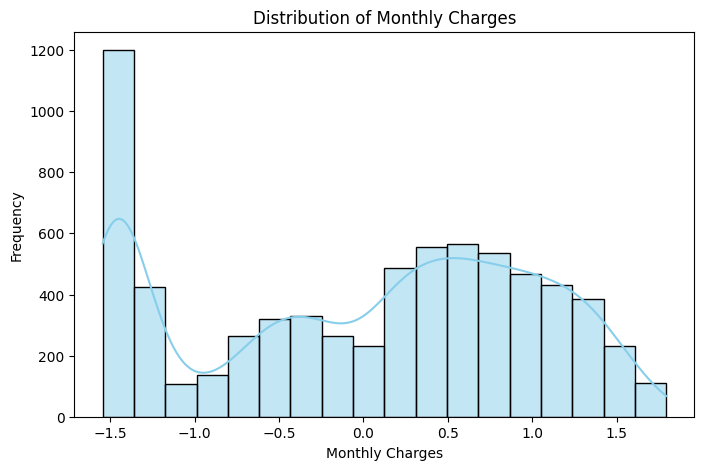

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], kde=True, color='skyblue')

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")

plt.show()

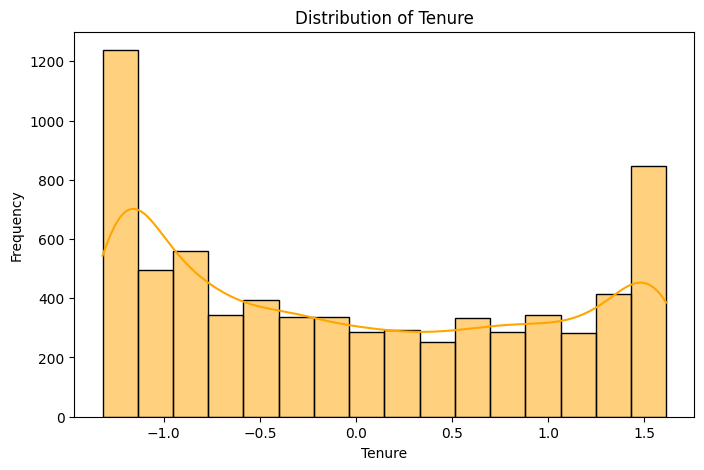

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], kde=True, color='orange')

plt.title("Distribution of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")

plt.show()

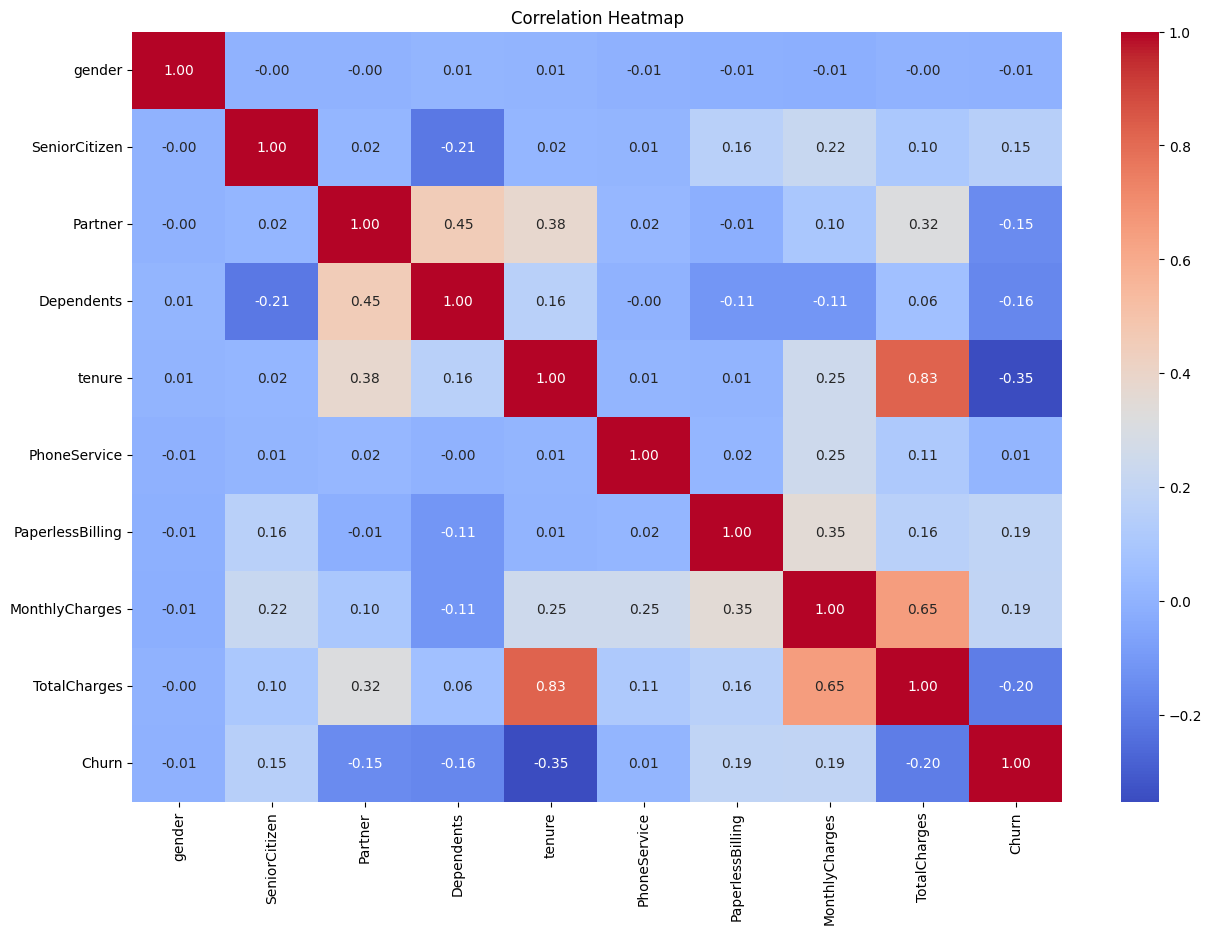

In [26]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [37]:
#Praveen Ramanan K                                                         #Exercise-2
#241801214                                                       #Data Discovery and Preparation
#AI&DS

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_raw = pd.read_csv(csv_path)
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'].astype(str).str.strip(), errors='coerce')
df_raw['TotalCharges'].fillna(df_raw['TotalCharges'].median(), inplace=True)


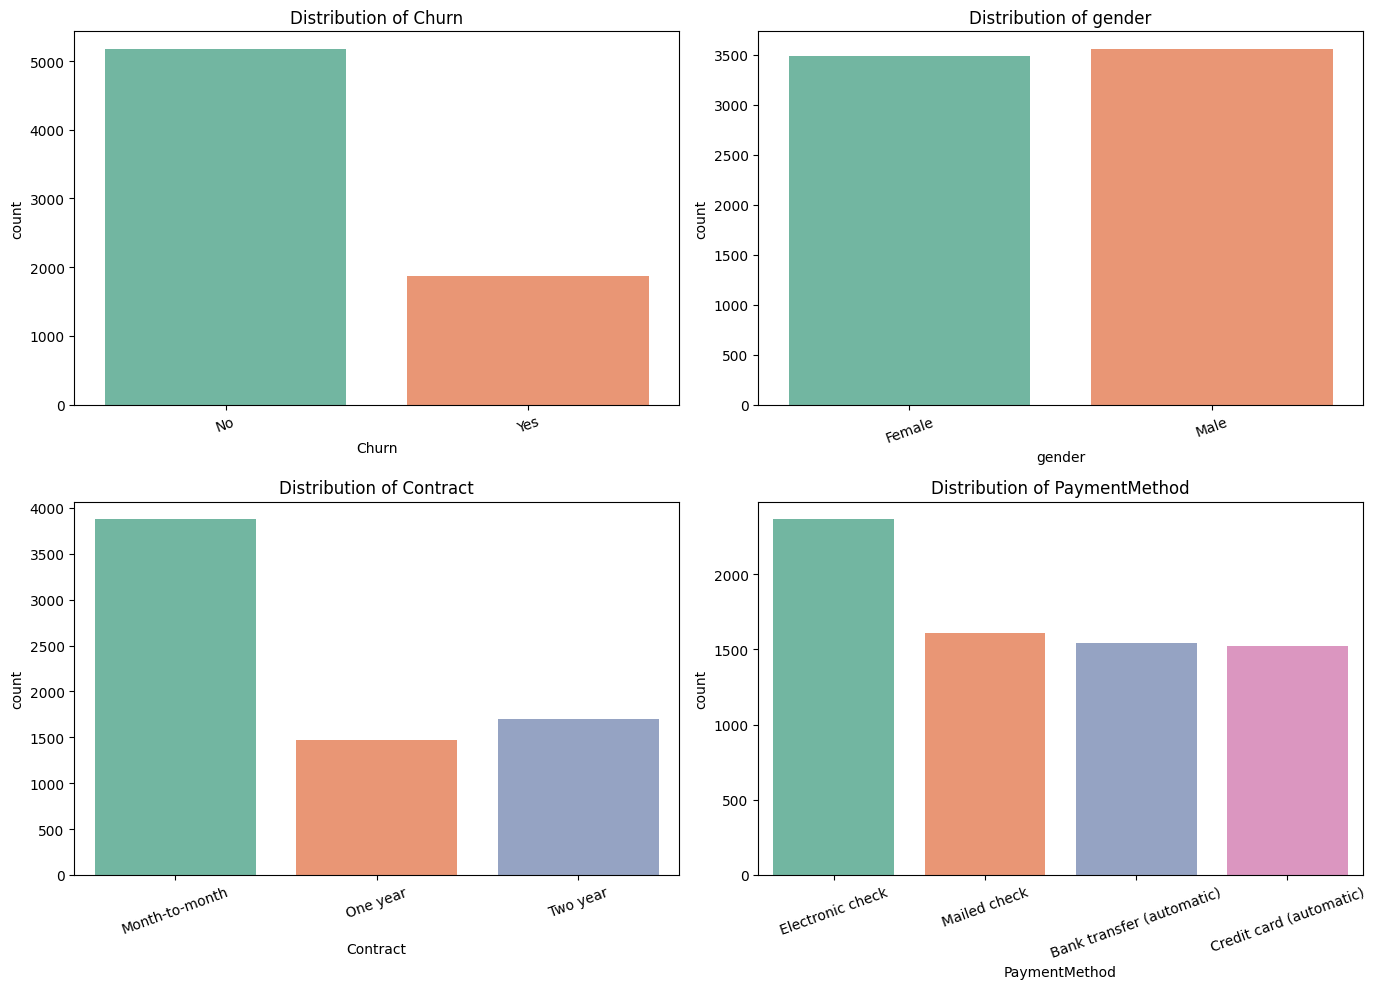

In [30]:
cat_features = ['Churn', 'gender', 'Contract', 'PaymentMethod']
plt.figure(figsize=(14, 10))

for i, col in enumerate(cat_features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df_raw, x=col, palette="Set2")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

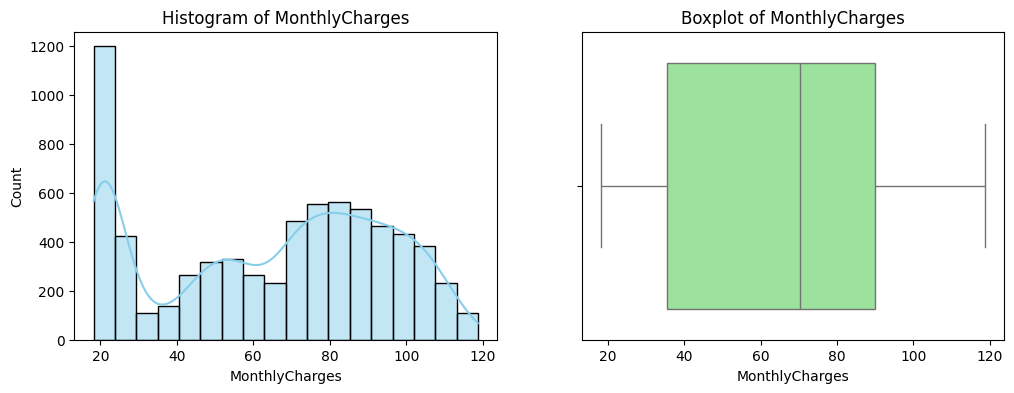

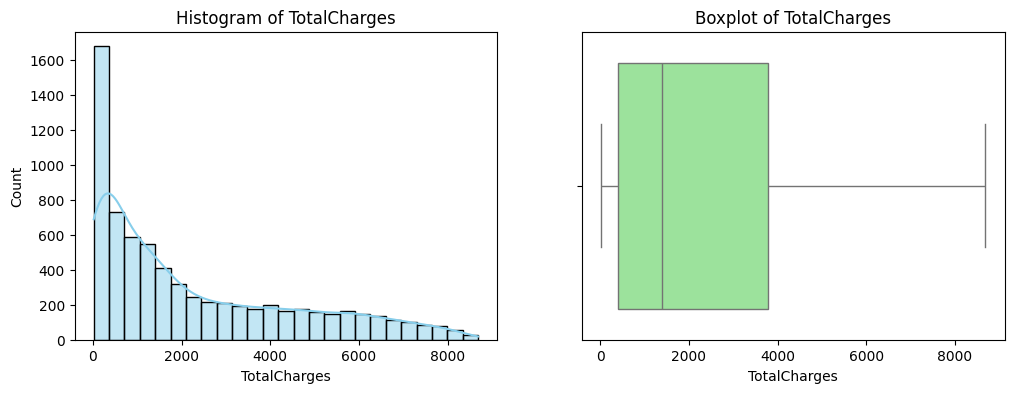

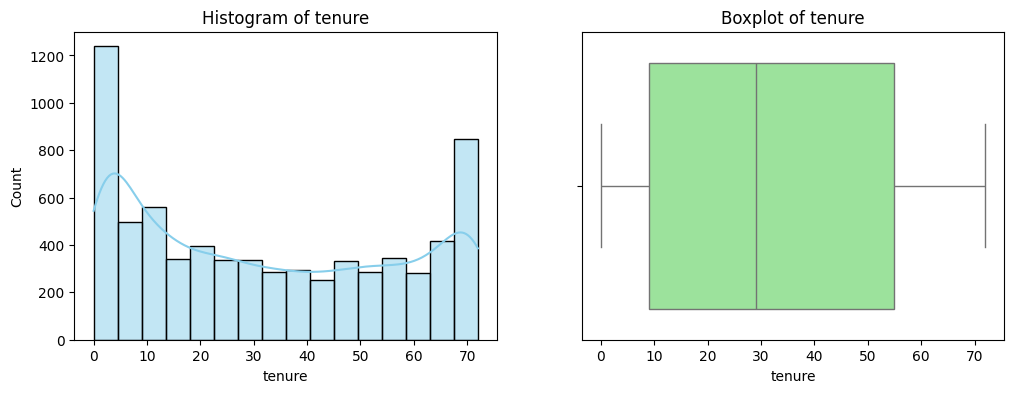

In [31]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure']

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df_raw[col], kde=True, ax=axes[0], color="skyblue")
    axes[0].set_title(f"Histogram of {col}")

    sns.boxplot(x=df_raw[col], ax=axes[1], color="lightgreen")
    axes[1].set_title(f"Boxplot of {col}")
    plt.show()

In [32]:
print("--- IQR Outlier Detection ---")
for col in num_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_raw[(df_raw[col] < lower_bound) | (df_raw[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} outliers (Lower: {lower_bound:.2f}, Upper: {upper_bound:.2f})")

--- IQR Outlier Detection ---
MonthlyCharges: Found 0 outliers (Lower: -46.02, Upper: 171.38)
TotalCharges: Found 0 outliers (Lower: -4674.34, Upper: 8863.16)
tenure: Found 0 outliers (Lower: -60.00, Upper: 124.00)


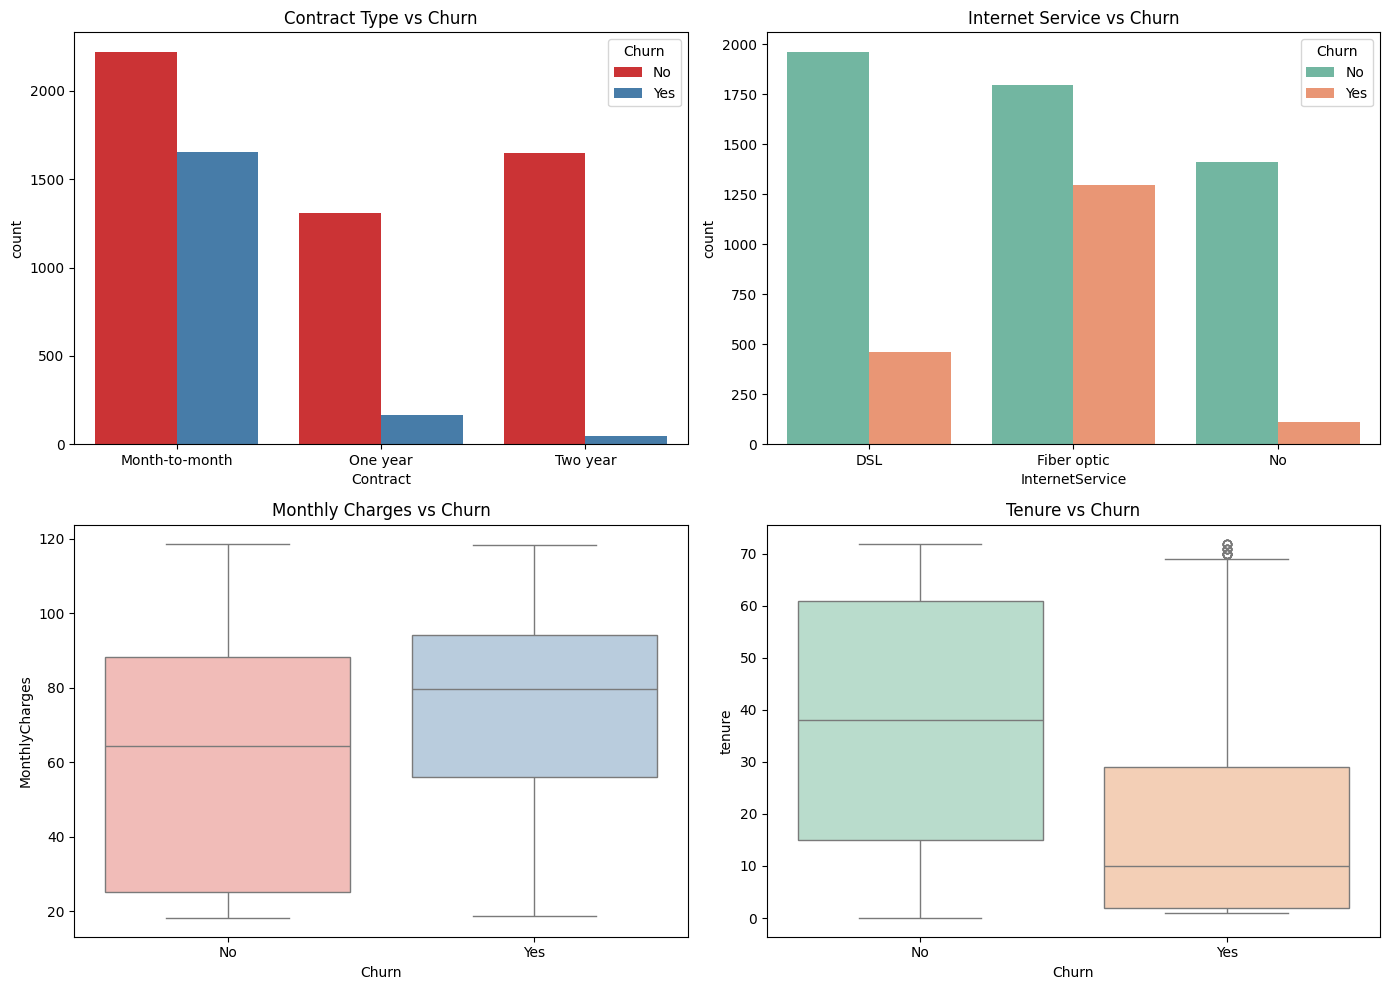

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_raw, x='Contract', hue='Churn', ax=axes[0, 0], palette="Set1")
axes[0, 0].set_title("Contract Type vs Churn")

sns.countplot(data=df_raw, x='InternetService', hue='Churn', ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Internet Service vs Churn")

sns.boxplot(data=df_raw, x='Churn', y='MonthlyCharges', ax=axes[1, 0], palette="Pastel1")
axes[1, 0].set_title("Monthly Charges vs Churn")

sns.boxplot(data=df_raw, x='Churn', y='tenure', ax=axes[1, 1], palette="Pastel2")
axes[1, 1].set_title("Tenure vs Churn")

plt.tight_layout()
plt.show()

In [34]:
churned_df = df_raw[df_raw['Churn'] == 'Yes']
non_churned_df = df_raw[df_raw['Churn'] == 'No']

print("--- ANALYTICAL QUESTIONS & ANSWERS ---")
print("1. Highest churn contract type:", churned_df['Contract'].value_counts().idxmax())
print("2. Most frequent payment method for churned customers:", churned_df['PaymentMethod'].value_counts().idxmax())
print(f"3. Do shorter tenure customers churn more? YES. (Avg Tenure Churned: {churned_df['tenure'].mean():.1f} mos vs Non-churned: {non_churned_df['tenure'].mean():.1f} mos)")
print("4. Customer group with highest monthly charges:", df_raw.groupby('InternetService')['MonthlyCharges'].mean().idxmax())
print("5. Internet Service category with highest churn:", churned_df['InternetService'].value_counts().idxmax())
print("6. Relationship between monthly charges & churn: Churned customers have significantly higher median monthly charges (~$80+).")
print("7. Strongest indicators of customer churn: Short Tenure, Month-to-Month Contract, Fiber Optic Internet, and Electronic Check Payment.")

--- ANALYTICAL QUESTIONS & ANSWERS ---
1. Highest churn contract type: Month-to-month
2. Most frequent payment method for churned customers: Electronic check
3. Do shorter tenure customers churn more? YES. (Avg Tenure Churned: 18.0 mos vs Non-churned: 37.6 mos)
4. Customer group with highest monthly charges: Fiber optic
5. Internet Service category with highest churn: Fiber optic
6. Relationship between monthly charges & churn: Churned customers have significantly higher median monthly charges (~$80+).
7. Strongest indicators of customer churn: Short Tenure, Month-to-Month Contract, Fiber Optic Internet, and Electronic Check Payment.


In [38]:
X = df.drop(columns=['Churn', 'customerID'], errors='ignore')
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

df.to_csv("CustomerChurn_Preprocessed.csv", index=False)
print("\nSuccessfully saved 'CustomerChurn_Preprocessed.csv'!")

Training set shape: (5634, 19)
Testing set shape: (1409, 19)

Successfully saved 'CustomerChurn_Preprocessed.csv'!
